<font color='red'><b>**WARNING**</b></font> <br/>
어떠한 사유로도 임의로 복사, 촬영, 녹음, 복제, 보관, 전송하거나 허가 받지 않은 저장매체를 이용한 보관, 제3자에게 누설, 공개 또는 사용하는 등의 무단 사용 및 불법 배포 시 법적 조치를 받을 수 있습니다. <br/>

<div style="text-align: right; color: #7f8c8d; font-size: 0.9em; margin-top: 20px;">
📝 Author: 박사홍 (Sahong Pak)</br>
📧 Contact: sahong.pak@gmail.com</br>
📌 Version: v2.0</br>
📅 Last Updated: 2026-03-12</br>
</div>

</br>

# 학습 내용
>이번 장에서는 <strong>텍스트-투-이미지 생성(Text-to-Image Generation)</strong>에 대해 학습합니다.</br></br>
>Diffusion 모델의 원리와 Stable Diffusion 파이프라인을 활용한 이미지 생성을 학습해봅시다.

</br>

# Diffusion 모델 (Diffusion Model)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">노이즈를 점진적으로 제거</mark>하여 이미지를 생성하는 생성 모델입니다.

텍스트-투-이미지 생성은 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">디자인 프로토타이핑, 창작, 광고 소재 제작</mark> 등에서 전문 디자인 도구 없이도 아이디어를 즉시 시각화할 수 있게 합니다. Diffusion 모델의 핵심 아이디어는 먼저 원본 이미지에 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가우시안 노이즈를 단계적으로 추가(Forward Process)</mark>하여 순수 노이즈 상태로 만든 뒤, 이 과정을 역으로 학습하는 것입니다. 학습 후에는 순수 노이즈에서 출발해 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">노이즈를 단계적으로 제거(Reverse Process)</mark>하며 이미지를 생성하고, 텍스트 프롬프트는 CLIP 텍스트 인코더를 통해 이 디노이징 과정을 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">원하는 방향으로 안 내</mark>합니다.</br>이 장에서 다루는 내용을 이해하려면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">가우시안 노이즈</mark>(정규분포를 따르는 무작위 노이즈), <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">U-Net</mark>(인코더-디코더 구조의 신경망으로 노이즈 예측기로 활용), <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">CLIP 텍스트 인코더</mark>(텍스트를 이미지와 동일한 임베딩 공간에 매핑하여 조건 신호로 제공)에 대한 기본 개념이 필요합니다.

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">과정</th>
      <th>설명</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center">Forward (노이즈 추가)</td><td>원본 이미지에 점진적으로 노이즈 추가</td></tr>
    <tr><td style="text-align:center"><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">Reverse (디노이징)</mark></td><td>노이즈에서 이미지를 복원하도록 학습</td></tr>
  </tbody>
</table>

</br>

## Stable Diffusion Pipeline
> Hugging Face `diffusers` 라이브러리로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">텍스트 프롬프트에서 이미지를 생성</mark>합니다.

In [1]:
# TODO 1: Stable Diffusion 파이프라인을 사전학습 모델로부터 로드하고, 고양이가 창턱에 앉아 있는 석양 장면을 프롬프트로 지정하여 이미지를 생성해봅시다.

from diffusers import StableDiffusionPipeline
import torch

pipe = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16
).to("cuda")

image = pipe(
    prompt="a photo of a cat sitting on a windowsill, sunset",
    num_inference_steps=50,
    guidance_scale=7.5
).images[0]

image.save("generated.png")
print(f"이미지 크기: {image.size}")
print(f"이미지 모드: {image.mode}")

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

c:\Users\SSAFY\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\SSAFY\.cache\huggingface\hub\models--runwayml--stable-diffusion-v1-5. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

이미지 크기: (512, 512)
이미지 모드: RGB


💡생성 결과
> GPU 환경에서 실행하면 석양을 배경으로 창턱에 앉아 있는 고양이 사진 스타일의 이미지가 생성됩니다.</br>
> Stable Diffusion 기본 해상도인 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">512x512</mark> 크기로 출력됩니다.

</br>

## 주요 파라미터

<table style="width:100%">
  <thead>
    <tr>
      <th style="text-align:center">파라미터</th>
      <th>설명</th>
      <th style="text-align:center">권장값</th>
    </tr>
  </thead>
  <tbody>
    <tr><td style="text-align:center"><code>prompt</code></td><td>생성할 이미지 설명</td><td style="text-align:center">구체적으로</td></tr>
    <tr><td style="text-align:center"><code>num_inference_steps</code></td><td>디노이징 단계 수</td><td style="text-align:center">30~50</td></tr>
    <tr><td style="text-align:center"><code>guidance_scale</code></td><td><mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">프롬프트 충실도</mark></td><td style="text-align:center">7.0~8.5</td></tr>
    <tr><td style="text-align:center"><code>negative_prompt</code></td><td>제외할 요소</td><td style="text-align:center">선택사항</td></tr>
    <tr><td style="text-align:center"><code>seed</code></td><td>재현성을 위한 시드</td><td style="text-align:center">정수</td></tr>
  </tbody>
</table>

💡guidance_scale 이해
> 낮은 값(1~3): 다양하지만 프롬프트 무시 경향</br>
> 높은 값(10+): 프롬프트에 충실하지만 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">과포화/아티팩트</mark> 발생</br>
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">7.5</mark> 전후가 일반적으로 좋은 균형점입니다.

</br>

## 프롬프트 작성 팁

In [2]:
# TODO 2: 주제, 스타일, 조명, 품질 키워드를 포함한 상세 프롬프트와 제외할 요소를 지정하는 네거티브 프롬프트를 활용하여 고품질 이미지를 생성해봅시다.

# "주제, 스타일, 조명, 구도, 품질 키워드"

prompt = "a golden retriever puppy, studio photography, soft lighting, 4k, detailed"
negative = "blurry, low quality, distorted"

image = pipe(prompt=prompt, negative_prompt=negative).images[0]
print(f"생성 완료: {image.size}")

  0%|          | 0/50 [00:00<?, ?it/s]

생성 완료: (512, 512)


💡생성 결과
> 스튜디오 조명 아래 골든 리트리버 강아지 사진이 생성됩니다.</br>
> `negative_prompt`로 "blurry, low quality"를 지정하여 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">선명하고 고품질</mark>의 이미지가 출력됩니다.

💡SanaPipeline vs StableDiffusionPipeline
> SanaPipeline은 경량화된 모델로 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">빠른 생성</mark>에 적합합니다.</br>
> Stable Diffusion은 더 높은 품질이지만 GPU 메모리를 많이 사용합니다.

</br>

## 시드 제어 (Seed Control)
> <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">동일한 시드 = 동일한 노이즈 = 동일한 이미지</mark>를 생성합니다.
> `torch.Generator`로 초기 노이즈를 고정하면, 같은 프롬프트에서 재현 가능한 결과를 얻을 수 있습니다.

In [3]:
# TODO 3: 시드를 지정하여 재현 가능한 이미지를 생성해봅시다.

generator_a = torch.Generator(device="cuda").manual_seed(42)
image_seed_42 = pipe(prompt, generator=generator_a, num_inference_steps=50).images[0]

print(f"시드 42 이미지 크기: {image_seed_42.size}")

  0%|          | 0/50 [00:00<?, ?it/s]

시드 42 이미지 크기: (512, 512)


In [4]:
# TODO 4: 다른 시드로 생성하여 결과가 달라지는지 확인해봅시다.

generator_b = torch.Generator(device="cuda").manual_seed(777)
image_seed_777 = pipe(prompt, generator=generator_b, num_inference_steps=50).images[0]

print(f"시드 777 이미지 크기: {image_seed_777.size}")

  0%|          | 0/50 [00:00<?, ?it/s]

시드 777 이미지 크기: (512, 512)


C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_7524\22761951.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.

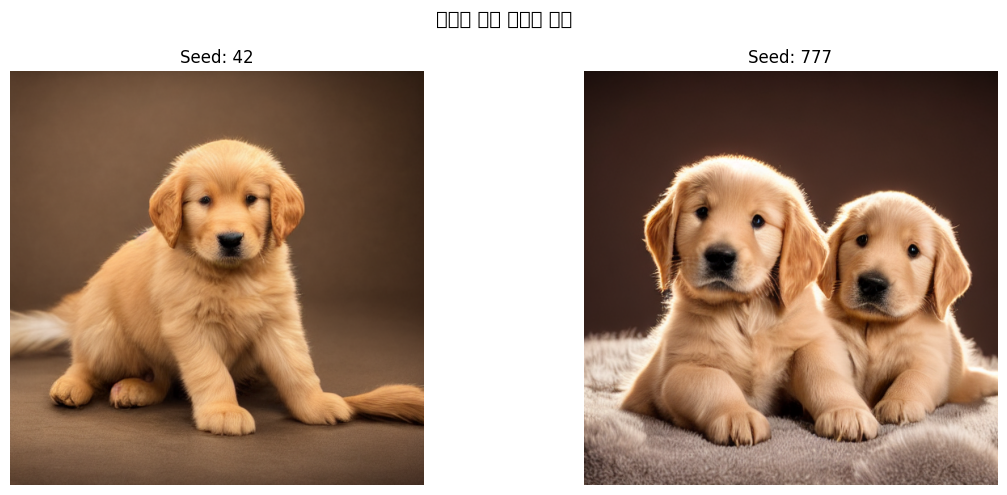

In [5]:
# TODO 5: 두 이미지를 나란히 비교해봅시다.

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(image_seed_42)
axes[0].set_title("Seed: 42")
axes[0].axis("off")
axes[1].imshow(image_seed_777)
axes[1].set_title("Seed: 777")
axes[1].axis("off")
plt.suptitle("시드에 따른 이미지 변화", fontsize=14)
plt.tight_layout()
plt.show()

💡시드와 다양성
> 같은 시드를 사용하면 <mark style="background-color:#FFF9C4; padding:2px 6px; border-radius:4px;">실험의 재현성</mark>을 보장합니다.</br>
> 다양한 이미지가 필요하면 시드를 변경하거나, 여러 시드를 반복 생성하여 최적의 결과를 선택합니다.